# Chapter 18. Combining Datasets

Often times, when loading data from different sources, we must combine multiple data frames into one. These operations can be as simple as a concatenation, when the columns match, or a more complex database-style join.

In [39]:
# Default imports
import pandas as pd
import numpy as np

## Concat

The first method we will study is through the concatenation of `Series` and `DataFrame`s with `pd.concat`.

In [40]:
# The following function quickly creates a data frame

def make_df(cols, ind):
    """Quickly make a DataFrame"""
    data = {c: [str(c) + str(i) for i in ind]
        for c in cols}
    return pd.DataFrame(data, ind)

make_df("ABC", range(3))

,A,B,C
0,A0,B0,C0
1,A1,B1,C1
2,A2,B2,C2


We will utilize the following class to display multiple `DataFrame` objects side by side. 

In [41]:
class display(object):
    """Display HTML representation of multiple objects"""
    template = """<div style="float: left; padding: 10px;">
    <p style='font-family:"Courier New", Courier, monospace'>{0}{1}
    """
    def __init__(self, *args):
        self.args = args

    def _repr_html_(self):
        return ' '.join(self.template.format(a, eval(a)._repr_html_())
                            for a in self.args)

    def __repr__(self):
        return ' '.join(a + ' ' + repr(eval(a))
                            for a in self.args)

Concatenation of `Series` and `DataFrame` objects are similar to the concatenation of NumPy arrays (`np.concatenate`).
Recall how `np.concatenate` works:

In [42]:
x = [1, 2, 3]
y = [4, 5, 6]
z = [7, 8, 9]
np.concatenate([x, y, z])

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

For multidimensional arrays, we can use the `axis` keyword to determine the axis along which the concatenation will take place:

In [43]:
x = [[1, 2],
    [3, 4]]
np.concatenate([x, x], axis=1)


array([[1, 2, 1, 2],
       [3, 4, 3, 4]])

### Concatenation with `pd.concat`

The general syntax:

```python
pd.concat(objs, axis=0, join='outer', ignore_index=False, keys=None,
          levels=None, names=None, verify_integrity=False,
          sort=False, copy=True)
```

`pd.concat` can be used for a simple concatenation of `Series` and `DataFrame`.

The first positional argument `objs` must be a sequence of `Series` or a sequence of `DataFrames`, whichever you would like to concatenate. _Recall_: a sequence can be any iterable such as an array, a list, or a tuple.

In [44]:
ser1 = pd.Series(['A', 'B', 'C'], index=[1, 2, 3])
ser2 = pd.Series(['D', 'E', 'F'], index=[4, 5, 6])
pd.concat([ser1, ser2])

1    A
2    B
3    C
4    D
5    E
6    F
dtype: object

Concatenating `DataFrame` objects:

In [45]:
df1 = make_df('AB', [1, 2])
df2 = make_df('AB', [3, 4])
display('df1', 'df2', 'pd.concat([df1, df2])')

,A,B
1,A1,B1
2,A2,B2
,A,B
3,A3,B3
4,A4,B4
,A,B
1,A1,B1
2,A2,B2
3,A3,B3
4,A4,B4


What if the data frame columns do not match?

In [46]:
df3 = make_df('DC', [1,2])
display('df1', 'df3', 'pd.concat([df1, df3])')

df1     A   B
1  A1  B1
2  A2  B2 df3     D   C
1  D1  C1
2  D2  C2 pd.concat([df1, df3])      A    B    D    C
1   A1   B1  NaN  NaN
2   A2   B2  NaN  NaN
1  NaN  NaN   D1   C1
2  NaN  NaN   D2   C2

The default behavior is to concatenate __rows__ of the `DataFrame` (`axis=0`).

In [47]:
df3 = make_df('AB', [0, 1])
df4 = make_df('CD', [1, 2])
display('df3', 'df4', "pd.concat([df3, df4], axis='columns')")

df3     A   B
0  A0  B0
1  A1  B1 df4     C   D
1  C1  D1
2  C2  D2 pd.concat([df3, df4], axis='columns')      A    B    C    D
0   A0   B0  NaN  NaN
1   A1   B1   C1   D1
2  NaN  NaN   C2   D2

### Duplicate indices

`pd.concat` will _preserve indices_ of the combined data frames:

In [48]:
x = make_df('AB', [0, 1])
y = make_df('CD', [2, 3])
y.index = x.index  # make indices match
display('x', 'y', 'pd.concat([x, y])')

x     A   B
0  A0  B0
1  A1  B1 y     C   D
0  C2  D2
1  C3  D3 pd.concat([x, y])      A    B    C    D
0   A0   B0  NaN  NaN
1   A1   B1  NaN  NaN
0  NaN  NaN   C2   D2
1  NaN  NaN   C3   D3

### Ignoring the index

One solution to the repeated index issue from above is to use the `ignore_index` flag. This will create a new integer index in the new `DataFrame`:

In [49]:
display('x', 'y', 'pd.concat([x, y], ignore_index=True)')

x     A   B
0  A0  B0
1  A1  B1 y     C   D
0  C2  D2
1  C3  D3 pd.concat([x, y], ignore_index=True)      A    B    C    D
0   A0   B0  NaN  NaN
1   A1   B1  NaN  NaN
2  NaN  NaN   C2   D2
3  NaN  NaN   C3   D3

### The `append` method

The `append` method for `Series` and `DataFrame` works similarly to `append` from `list`.

Its main purpose is to perform concatenation in place. Instead of calling `pd.concat([df1, df2])` you can just type `df1.append(df2)`.

## Chapter 19. Merge and Join

Pandas offers a high-performance, in-memory join and merge operations akin to database joins. The main interface for this is the `pd.merge` function.

The general idea of joining `DataFrame` is that we will have a __left__ `DataFrame` and __right__ `DataFrame` to join.

__Merge__: Input is _two_ `DataFrame` objects. Output is _one_ `DataFrame` object combining the input.

### Relational algebra

The behavior of `pd.merge` follows the principles of _relational algebra_, a formal set of rules for manipulating relation data. _Relational algebra_ is the building block upon which relational databases are made, providing efficient interfaces to data manipulation and retrieval.

### One-to-one joins


One of the simplest types of merge. Similar to column-wise concatenation.

In [50]:
df1 = pd.DataFrame({'employee': ['Bob', 'Jake', 'Lisa', 'Sue'],
                            'group': ['Accounting', 'Engineering',
                                      'Engineering', 'HR']})
df2 = pd.DataFrame({'employee': ['Lisa', 'Bob', 'Jake', 'Sue'],
                    'hire_date': [2004, 2008, 2012, 2014]})
display('df1', 'df2')

,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR
,employee,hire_date
0,Lisa,2004
1,Bob,2008
2,Jake,2012
3,Sue,2014


To combine the data frames from above into a single `DataFrame` object, we can use `pd.merge`:

In [51]:
df3 = pd.merge(df1, df2)
df3

,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


### Many-to-one joins

Many-to-one joins are those where one of the two key columns contains duplicate entries. Consider the example:

In [52]:
df4 = pd.DataFrame({'group': ['Accounting', 'Engineering', 'HR'],
                            'supervisor': ['Carly', 'Guido', 'Steve']})
display('df3', 'df4', 'pd.merge(df3, df4)')

df3   employee        group  hire_date
0      Bob   Accounting       2008
1     Jake  Engineering       2012
2     Lisa  Engineering       2004
3      Sue           HR       2014 df4          group supervisor
0   Accounting      Carly
1  Engineering      Guido
2           HR      Steve pd.merge(df3, df4)   employee        group  hire_date supervisor
0      Bob   Accounting       2008      Carly
1     Jake  Engineering       2012      Guido
2     Lisa  Engineering       2004      Guido
3      Sue           HR       2014      Steve

In the above example, we would like to have a supervisor column added to `df3`. The information about supervisors is in `df4`. We must then merge both tables on the `group` column.

### Many-to-many joins

This type of join happens when key columns both on the left and right data frames contain duplicates.

In [53]:
df5 = pd.DataFrame({'group': ['Accounting', 'Accounting',
                                      'Engineering', 'Engineering', 'HR', 'HR'],
                            'skills': ['math', 'spreadsheets', 'software', 'math',
                                       'spreadsheets', 'organization']})
display('df1', 'df5', "pd.merge(df1, df5)")

,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR
,group,skills
0,Accounting,math
1,Accounting,spreadsheets
2,Engineering,software
3,Engineering,math
4,HR,spreadsheets


### Specification of the merge __key__

The default behavior of `pd.merge` is to __look for matching column names__ on both `DataFrame` objects. What to do when column names do not match?

#### The `on` keyword

You can specify the name of the key column using the `on` keyword of `pd.merge`:

In [54]:
display('df1', 'df2', "pd.merge(df1, df2, on='employee')")

df1   employee        group
0      Bob   Accounting
1     Jake  Engineering
2     Lisa  Engineering
3      Sue           HR df2   employee  hire_date
0     Lisa       2004
1      Bob       2008
2     Jake       2012
3      Sue       2014 pd.merge(df1, df2, on='employee')   employee        group  hire_date
0      Bob   Accounting       2008
1     Jake  Engineering       2012
2     Lisa  Engineering       2004
3      Sue           HR       2014

However, the above only works of column `'employee'` exists in __both data frames__.

#### The `left_on` and `right_on` keywords

More often than not, data frames originating from different sources may contain different column names. Thus, we must match a certain name on the left data frame with a different name on the right data frame. We use arguments `left_on` and `right_on` for this:

In [ ]:
df3 = pd.DataFrame({'name': ['Bob', 'Jake', 'Lisa', 'Sue'],
                            'salary': [70000, 80000, 120000, 90000]})
display('df1', 'df3', 'pd.merge(df1, df3, left_on="employee",right_on="name")')

### Speficifying the set arithmetic for join

The type of _set arithmetic_ used in the join determines the outcome of the data frame when a value appears in one key column but not in the other. For example:

In [55]:
df6 = pd.DataFrame({'name': ['Peter', 'Paul', 'Mary'],
                             'food': ['fish', 'beans', 'bread']},
                            columns=['name', 'food'])
df7 = pd.DataFrame({'name': ['Mary', 'Joseph'],
                    'drink': ['wine', 'beer']},
                columns=['name', 'drink'])
display('df6', 'df7', 'pd.merge(df6, df7)')

df6     name   food
0  Peter   fish
1   Paul  beans
2   Mary  bread df7      name drink
0    Mary  wine
1  Joseph  beer pd.merge(df6, df7)    name   food drink
0  Mary  bread  wine

Notice what happens to the merged data frame. The only `name` column entry present in both input data frames is Mary. By default, the join will show only the _intersection_ of both sets. This is known as __inner join__. Anything not in the intersection (both input tables at the same time) is left out.

The set arithmetic method can be determined using the `how` argument:

In [56]:
pd.merge(df6, df7, how='inner')

,name,food,drink
0,Mary,bread,wine


Other options are: `'outer'`, `'left'` and `'right'`.

An _outer join_ returns the union over the input sets, with missing values filled with `NaN`:

In [57]:
display('df6', 'df7', "pd.merge(df6, df7, how='outer')")

df6     name   food
0  Peter   fish
1   Paul  beans
2   Mary  bread df7      name drink
0    Mary  wine
1  Joseph  beer pd.merge(df6, df7, how='outer')      name   food drink
0  Joseph    NaN  beer
1    Mary  bread  wine
2    Paul  beans   NaN
3   Peter   fish   NaN

Try using `'left'` and `'right'` joins and see what the results are.

### Overlapping column names: using suffixes

When joining two `DataFrame` objects, there might be one or more column name conflicts:

In [61]:
df8 = pd.DataFrame({'name': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'last_name': ['A', 'B', 'C', 'D'],
                             'rank': [1, 2, 3, 4]})
df9 = pd.DataFrame({'name': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'last_name': ['A', 'B', 'C', 'D'],
                    'rank': [3, 1, 4, 2]})
display('df8', 'df9', 'pd.merge(df8, df9, on="name")')

df8    name last_name  rank
0   Bob         A     1
1  Jake         B     2
2  Lisa         C     3
3   Sue         D     4 df9    name last_name  rank
0   Bob         A     3
1  Jake         B     1
2  Lisa         C     4
3   Sue         D     2 pd.merge(df8, df9, on="name")    name last_name_x  rank_x last_name_y  rank_y
0   Bob           A       1           A       3
1  Jake           B       2           B       1
2  Lisa           C       3           C       4
3   Sue           D       4           D       2

Note how column `rank` is present in both inputs, presenting a conflict. Which of the two should appear in the output?

The solution is to have _both_ columns in the output. Pandas does that by applying a _suffix_ to each column (`_x` and `_y`). You can control the suffixes using the `suffixes` argument:

In [62]:
pd.merge(df8, df9, on=["name", "last_name"], suffixes=["_L", "_R"])

,name,last_name,rank_L,rank_R
0,Bob,A,1,3
1,Jake,B,2,1
2,Lisa,C,3,4
3,Sue,D,4,2


## Chapter 20. Aggregation and grouping

Pandas offers interfaces to data summarization techniques: `sum`, `mean`, `median`, `min`, `max`, among others.

We will import a toy dataset from the `seaborn` library, which will be studied later on in this course. (You can find more information about [seaborn datasets here](https://github.com/mwaskom/seaborn-data))

In [63]:
import seaborn as sns
planets = sns.load_dataset("planets")
planets.shape

(1035, 6)

The `'planets'` dataset includes information about over a thousand extrasolar planets discovered up to 2014.

In [64]:
planets.head()  # This shows the first few rows of the table.

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


By default, Pandas provides aggregate information about each column. For example, to get the _mean_ value of column _mass_ from above:

In [65]:
print(f"Average planet mass: {round(planets['mass'].mean(), 2)}")

Average planet mass: 2.64


To get an _overall_ description of the data, we can use the `describe()` method, which summarizes the entire data frame on some popular metrics, including counts, percentiles (25%, 50%, 75%), and average values:

In [66]:
planets.dropna().describe()

,number,orbital_period,mass,distance,year
count,498.00000,498.000000,498.000000,498.000000,498.000000
mean,1.73494,835.778671,2.509320,52.068213,2007.377510
std,1.17572,1469.128259,3.636274,46.596041,4.167284
min,1.00000,1.328300,0.003600,1.350000,1989.000000
25%,1.00000,38.272250,0.212500,24.497500,2005.000000
50%,1.00000,357.000000,1.245000,39.940000,2009.000000
75%,2.00000,999.600000,2.867500,59.332500,2011.000000
max,6.00000,17337.500000,25.000000,354.000000,2014.000000


#### Built-in Pandas aggregations

- `count`
- `first`, `last`
- `mean`, `median`
- `min`, `max`
- `std`, `var` (Std. dev. and variance)
- `mad`  (Mean Absolute Deviation)
- `prod` (Product of all items)
- `sum` (Sum of all items)

## Grouping: split, apply, combine

Often, we want to aggregate conditionally on some label or index. Thus, we use the `groupby` function. The split-apply-combine operation is an example of it:

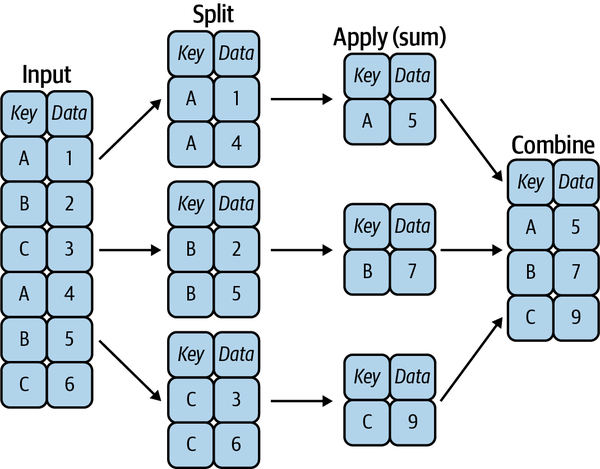

In [67]:
df = pd.DataFrame({'key': ['A', 'B', 'C', 'A', 'B', 'C'],
                            'data': range(6)}, columns=['key', 'data'])
df

,key,data
0,A,0
1,B,1
2,C,2
3,A,3
4,B,4
5,C,5


Using `groupby`:

In [68]:
df.groupby('key')

The returned object is a `DataFrameGroupBy`, and _not_ a set of `DataFrame` objects.
A `DataFrameGroupBy` works a a _special view_ of a regular `DataFrame`, organizing the rows into groups, but not doing any computation until the aggregation is applied.

To apply an aggregate, we can use some built-in functions, like `.sum()`:

In [69]:
df.groupby('key').sum()

,data
key,
A,3
B,5
C,7


### Column indexing

`GroupBy` supports column indexing just like a regular `DataFrame`:

In [70]:
planets.groupby('method')['orbital_period']

We have selected a series (`['orbital_period']`), group by each `method`. We can now aggregate on this column:

In [71]:
planets.groupby('method')['orbital_period'].median()

method
Astrometry                         631.180000
Eclipse Timing Variations         4343.500000
Imaging                          27500.000000
Microlensing                      3300.000000
Orbital Brightness Modulation        0.342887
Pulsar Timing                       66.541900
Pulsation Timing Variations       1170.000000
Radial Velocity                    360.200000
Transit                              5.714932
Transit Timing Variations           57.011000
Name: orbital_period, dtype: float64

Here, Astrometry, Eclipse Timing Variations, Imaging, are some of the _groups_ captured by the `GroupBy` in the `'method'` column.

### Iteration over groups

If you want to iterate over each group (usually for inspection and debugging purposes), you can do so with a for loop:

In [72]:
for (method, group) in planets.groupby('method'):
    print(f"{method:30s} shape={group.shape}")

Astrometry                     shape=(2, 6)
Eclipse Timing Variations      shape=(9, 6)
Imaging                        shape=(38, 6)
Microlensing                   shape=(23, 6)
Orbital Brightness Modulation  shape=(3, 6)
Pulsar Timing                  shape=(5, 6)
Pulsation Timing Variations    shape=(1, 6)
Radial Velocity                shape=(553, 6)
Transit                        shape=(397, 6)
Transit Timing Variations      shape=(4, 6)


#### Aggregation


The `aggregate` method offers an interface to perform multiple aggregations at once. It can take a string, a function or a list thereof and compute all aggregates:

In [73]:
rng = np.random.RandomState(0)
df = pd.DataFrame({'key': ['A', 'B', 'C', 'A', 'B', 'C'],
                'data1': range(6),
                'data2': rng.randint(0, 10, 6)},
                columns = ['key', 'data1', 'data2'])

df

,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


In [74]:
df.groupby('key').aggregate(['min', np.median, np.max])

/var/folders/47/1ghj32692yq0vz21g7gnm6g80000gr/T/ipykernel_88372/1835539408.py:1: FutureWarning: The provided callable <function median at 0x105a34ea0> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df.groupby('key').aggregate(['min', np.median, np.max])
/var/folders/47/1ghj32692yq0vz21g7gnm6g80000gr/T/ipykernel_88372/1835539408.py:1: FutureWarning: The provided callable <function max at 0x10572c720> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.groupby('key').aggregate(['min', np.median, np.max])


data1            data2           
      min median max   min median max
key                                  
A       0    1.5   3     3    4.0   5
B       1    2.5   4     0    3.5   7
C       2    3.5   5     3    6.0   9

### Transformation

The `.transform()` method allows a transformation to be applied in a group-wise fashion. For example, the following will center the coordinates in `data1` and `data2` based on the `mean` of each group:

In [75]:
def center(x):
    return x - x.mean()
df.groupby('key').transform(center)

,data1,data2
0,-1.5,1.0
1,-1.5,-3.5
2,-1.5,-3.0
3,1.5,-1.0
4,1.5,3.5
5,1.5,3.0


### The `apply` method

The `apply` method lets you apply an arbitrary function to the group results. The following uses `apply` to normalize the first column by the sum of the second, per group:

In [ ]:
def norm_by_data2(x):
    # x is a DataFrame of group values
    x['data1'] /= x['data2'].sum()
    return x

df.groupby('key').apply(norm_by_data2)